<a href="https://colab.research.google.com/github/marcheanin/hf_llm_course/blob/main/01_transformer_models/TransformerModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. NLP and LLM

### Что такое NLP

Это область машинного обучения, которая занимается всем, что связано с пониманием человеческого языка. Происходит это не пониманием отдельного слова, а пониманием контекста, в котором оно употребляется.

#### Базовые NLP-задачи:

- *Классификация предложений* - сентимент, детекторы спама, грамматическая точность предложения, определение связанности двух предложений.
- *Классификация каждого слова в предложении* - классификация по членам предложения, NER
- *Генерация текстового контента* - ответ на prompt авто-генерированным текстом, заполнение пробелов в тексте маскироваными словами
- *Генерация нового предложения из введенного текста* - дается вопрос или контекст, понимаем какой дать ответ на его основе.

#### Восхождение LLM



В последние годы наблюдается рост производительности моделей GPT-like архитектур.

GPT-модели обучены на огромном массиве текстовых данных, что позволяет им генерировать human-like тексты, различать паттерны языка, работая при этом с огромным разнообразием этих языков. При этом, они показывают высокую производительность на общих задачах, на которые не были специально натренерованы. В целом, такие модели показывают высокое развитие NLP в целом.

LLMs характеризуются через следующие критерии:

- Размер. Количество параметров
- Способность к генерализации. Способность решать различные задачи без специального дообучения под них
- Обучение контексту. Способность кардинально менять свое поведение (по сути обучаться) на переданном промптами контексту
- Неожиданные способности. При росте моделей в размере, они начинают демонстрировать способности, кототрые не зкладывались при обучении явно

Также есть выявленный спектр типичных проблем:

- Галлюцинации. LLM могут уверенно генерировать недостоверную информацию.
- Нехватка понимания мира. Модели не учатся реальному пониманию мира, а основываются на статистических закономерностях
- Bias. Могут уходить в сдвиги относительно их обучающих данных.
- Контекстное окно. LLM имеют ограниченное контекстное окно, дальше которого они не могут заглянуть
- LLM требуют высоких вычислительных мощностей.

##2. Transformers, what can they do?



#### Pipelines

Начнем с самого базового и высокоуровнего элемента HF-библиотеки - pipelines.

Использование - просто выбираем тип задачи, сетапим такой пайплайн и передаем туда текст для получения результата.

In [ ]:
!pip install --upgrade transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 80.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import pipeline

In [ ]:
classifier = pipeline("sentiment-analysis")

classifier("I've been waiting for a HuggingFace course my whole life.")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9598048329353333}]

Можем передать несколько сообщений

In [ ]:
classifier(
    ["I've been waiting for a HuggingFace course my whole life.", "I hate this so much!"]
)

[{'label': 'POSITIVE', 'score': 0.9598048329353333},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

Внутри, по дефолту, пайплайн выбирает предобученную модель, finetuned на анализ сентимента на Английском. Модель кэшируется, что позволяет ускорить повторные запуски.

Вот этапы, которые предусматривает пайплайн:

1. Текст проходит препроцессинг в формат, который понимает модель
2. Полученные входы поступают в модель
3. Предстказания модели преобразуются в конечный результат.

Вот список доступных задач для пайплайна:

Text pipelines
- text-generation: Generate text from a prompt
- text-classification: Classify text into predefined categories
- summarization: Create a shorter version of a text while preserving key - information
- translation: Translate text from one language to another
- zero-shot-classification: Classify text without prior training on specific labels
- feature-extraction: Extract vector representations of text

Image pipelines
- image-to-text: Generate text descriptions of images
- image-classification: Identify objects in an image
- object-detection: Locate and identify objects in images

Audio pipelines
- automatic-speech-recognition: Convert speech to text
- audio-classification: Classify audio into categories
- text-to-speech: Convert text to spoken audio

Multimodal pipelines
- image-text-to-text: Respond to an image based on a text prompt

Далее вставлю примеры работы этих видов пайплайнов

In [ ]:
# zero-shot classification

classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.8445985913276672, 0.11197450757026672, 0.04342687129974365]}

In [ ]:
# text generation

generator = pipeline("text-generation")
generator("In this course, we will teach you how to")

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'In this course, we will teach you how to create a web page to help you create a good experience.\n\nHow to create a good experience\n\nLet\'s start from the beginning:\n\nCreate an HTML page\n\nAdd a link to your webpage in the form of a link to your page.\n\nThe link will be in your JavaScript, and we will get to it in three different ways: by providing a link to your page, by creating a form, and by creating a form element.\n\nCreate a form element\n\nThe form element will be a simple, HTML document.\n\n<div class="container"> <input type="text" class="form-control"> <label class="action" for="create_form_id">Create an ID</label> <input type="text" class="form-control"> <label class="action" for="create_form_value">Create a value</label> <button type="submit" class="btn btn-primary" class="btn btn-default" data-control="create_form_id" data-class="form-control" data-label="create_form_value" data-class="form-control" data-label-text="create_form_value" data'}]

Также, можно самому выбирать модель, которая будет совершать действия в пайплайне

In [ ]:
generator = pipeline("text-generation", model="HuggingFaceTB/SmolLM2-360M")
generator(
    "In this course, we will teach you how to",
    max_length=30,
    num_return_sequences=2,
)

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "In this course, we will teach you how to do just that! We will provide you with the necessary tools and techniques to create your own virtual worlds, complete with interactive elements and dynamic gameplay. So grab your thinking caps, because we're about to embark on a thrilling journey into the realm of virtual reality!\n\nFirst, let's define what we mean by virtual reality. Simply put, virtual reality refers to the artificial construction of a simulated environment that can be experienced by a user. This means that instead of wearing a pair of special goggles or sitting in front of a computer screen, you would wear a headset or use a VR device to immerse yourself in a three-dimensional virtual space.\n\nNow, you might be wondering why we think it's important for high school students to learn how to create virtual worlds. Well, there are several reasons. First and foremost, creating virtual worlds can be a fun and rewarding hobby that allows you to express yoursel

In [ ]:
# mask fiiling

unmasker = pipeline("fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)

# top-k контролирует, сколько топовых по распределению вариантов будет выведено. Специальнвй токен не всегда обозначается как <mask>,
# это стоит проверять у провайдера модели

No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: distilbert/distilroberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[{'score': 0.19619713723659515,
  'token': 30412,
  'token_str': ' mathematical',
  'sequence': 'This course will teach you all about mathematical models.'},
 {'score': 0.040527280420064926,
  'token': 38163,
  'token_str': ' computational',
  'sequence': 'This course will teach you all about computational models.'}]

In [ ]:
# named entity recognition

ner = pipeline("ner", model="dbmdz/bert-large-cased-finetuned-conll03-english")
# В новых версиях transformers вместо grouped_entities используется aggregation_strategy
ner("My name is Sylvain and I work at Hugging Face in Brooklyn.", aggregation_strategy="simple")

# параметр aggregation_strategy (ранее grouped_entities) отвечает за объединение токенов, относящихся к одной сущности

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity_group': 'PER',
  'score': np.float32(0.9981694),
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': np.float32(0.9796019),
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': np.float32(0.9932106),
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

In [ ]:
# question answeting

question_answerer = pipeline("question-answering")
question_answerer(
    question="Where do I work?",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn",
)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'score': 0.6949770450592041, 'start': 33, 'end': 45, 'answer': 'Hugging Face'}

In [ ]:
# summarization (deprecated)
summarizer = pipeline("summarization")
summarizer(
    """
    America has changed dramatically during recent years. Not only has the number of
    graduates in traditional engineering disciplines such as mechanical, civil,
    electrical, chemical, and aeronautical engineering declined, but in most of
    the premier American universities engineering curricula now concentrate on
    and encourage largely the study of engineering science. As a result, there
    are declining offerings in engineering subjects dealing with infrastructure,
    the environment, and related issues, and greater concentration on high
    technology subjects, largely supporting increasingly complex scientific
    developments. While the latter is important, it should not be at the expense
    of more traditional engineering.

    Rapidly developing economies such as China and India, as well as other
    industrial countries in Europe and Asia, continue to encourage and advance
    the teaching of engineering. Both China and India, respectively, graduate
    six and eight times as many traditional engineers as does the United States.
    Other industrial countries at minimum maintain their output, while America
    suffers an increasingly serious decline in the number of engineering graduates
    and a lack of well-educated engineers.
"""
)

KeyError: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [ ]:
# translation (deprecated)

translator = pipeline("translation", model="Helsinki-NLP/opus-mt-fr-en")
translator("Ce cours est produit par Hugging Face.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

KeyError: "Unknown task translation, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [ ]:
# image classification

from transformers import pipeline

image_classifier = pipeline(
    task="image-classification", model="google/vit-base-patch16-224"
)
result = image_classifier(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
)
print(result)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


[{'label': 'lynx, catamount', 'score': 0.4334994852542877}, {'label': 'cougar, puma, catamount, mountain lion, painter, panther, Felis concolor', 'score': 0.03479618951678276}, {'label': 'snow leopard, ounce, Panthera uncia', 'score': 0.03240194171667099}, {'label': 'Egyptian cat', 'score': 0.023944808170199394}, {'label': 'tiger cat', 'score': 0.022889263927936554}]


In [ ]:
# speech recognition

from transformers import pipeline

transcriber = pipeline(
    task="automatic-speech-recognition", model="openai/whisper-large-v3"
)
result = transcriber(
    "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac"
)
print(result)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits pr

{'text': ' I have a dream that one day this nation will rise up and live out the true meaning of its creed.'}


## 3. How do transformers work

Это техническая глава про архитектуру трансформеров и их развитие, не хочк подробно расписываать эту информацию, слишком заезженно и местами не актуально.

Пару важных понятий:

#### Архитектура vs. Checkpoints

Архитектура - это скелет модели: сколько слоев, какие методы внимания и размерности выбраны и т д\
Чекпоинты - это Веса, которые обучены для конкретной архитектуры\
Модель - это и архитетура и чекпоинт, может испоьзоваться в разных контекстах, поэтому чтобы избежать путаницы, тут будем ипользовать один их двух вышеупомянутых терминов.

## 4. How transformers solve tasks

#### Transformer models for language

LLM задизайнены так, чтобы работать именно с языком, текстовой информацией. Они учатся устанавливать семантическую связь между токенами в переданном тексте.\

Изначально, модели делались для машинного перевода. Потом, архитектура распалась в применении на encoder и decoder - каждая их этих частей нашла применение в различных задачах.

#### Как работают языковые модели

Модели были обучаны предсказывать вероятность следующего токена на основе предыдущих или окружающих.

Есть два основных подхода в обучении моделей:

1. Masked Language Modeling (MLM). Используется для энкодеров. Этот подход рандомно маскирует токены и заставляет модель предсказывать их, таким образом обучая. Это позволяет модели изучать двусторонний контекст, и таким образом формировать представление о токене.
2. Causal Language Modeling (CLM). Это метод обучение декодера. Он учится предсказывать следующий токен на основе всех предыдущих ему переданных. Модель может использовать, таким образом, только левый контекст.

Логично, модели разбиваются на 3 вида:

1. Encoder-only. Состоят только из энкодера, используют бинаправленную информацию для обучения и решают соответствующие задачи, связанные с формированием представлений - классификация, NER, ответы на вопросы

2. Decoder-only. Все современные LLM - ипользуются для генерации текста.
3. Encoder-decoder models. Используют комбинацию обоих подходов. Подходят для машинного перевода, sequence-to-sequence задач.

## 1. Текстовые Модальности (NLP)

### 1.1. Генерация Текста (Decoder-Only)
*   **Базовая архитектура:** GPT-2.
*   **Токенизация:** Byte Pair Encoding (BPE) — создание подсловных (subword) эмбеддингов.
*   **Позиционирование:** Добавление позиционных кодировок (Positional Encodings) к эмбеддингам токенов.
*   **Механизм внимания:** **Маскированное самовнимание (Masked Self-Attention)**. Отличие от BERT: используется маска внимания, обнуляющая скоринг для будущих токенов (запрет на "подглядывание" вперед). Это обеспечивает авторегрессионность.
*   **Выходной слой (Head):** Языковая голова (Language Modeling Head) — линейное преобразование (`Linear`) скрытых состояний в логиты (размерность словаря).
*   **Функция потерь:** Кросс-энтропия (Cross-Entropy Loss). Логиты сдвигаются вправо на 1 позицию, чтобы меткой (label) для текущего токена служил следующий токен последовательности.
*   **Цель предобучения:** Причинное моделирование языка (Causal Language Modeling) — предсказание следующего слова.

### 1.2. Классификация Текста и Понимание (Encoder-Only)
*   **Базовая архитектура:** BERT.
*   **Токенизация:** WordPiece.
    *   Специальные токены: `[CLS]` (в начало последовательности) и `[SEP]` (разделитель предложений).
    *   Сегментные эмбеддинги (Segment Embeddings): идентификация принадлежности токена к первому или второму предложению в паре.
*   **Предобучение BERT (Двухзадачное):**
    1.  **MLM (Masked Language Modeling):** Случайное маскирование процента входных токентов. Предсказание исходного токена на основе финального скрытого состояния замаскированной позиции через FFN + Softmax. Решает проблему "двунаправленного читерства".
    2.  **NSP (Next Sentence Prediction):** Бинарная классификация, следует ли предложение B за предложением A. Вход: `[CLS] A [SEP] B [SEP]`. Выход: логиты классов `IsNext`/`NotNext` через FFN.
*   **Адаптация под задачи (Fine-tuning):**
    *   **Классификация последовательностей (Sequence Classification):** Поверх `[CLS]` токена добавляется линейный слой (Sequence Classification Head). Преобразование скрытого состояния `[CLS]` в логиты классов. Loss: кросс-энтропия.
    *   **Токен-классификация (Token Classification, NER):** Добавление линейного слоя поверх *каждого* финального скрытого состояния токена для присвоения метки каждому токену. Loss: кросс-энтропия (поэлементно).
    *   **Вопросно-ответные системы (Question Answering):** Добавление линейного слоя (Span Classification Head) для вычисления логитов старта и конца ответа (start/end logits) на основе финальных скрытых состояний контекста. Loss: кросс-энтропия между логитами и истинными позициями.

### 1.3. Seq2Seq задачи (Encoder-Decoder)
*   **Базовая архитектура:** BART, T5.
*   **Механизм BART:**
    *   **Кодировщик (Encoder):** Архитектура, подобная BERT. Принимает эмбеддинги токенов + позиций.
    *   **Стратегия предобучения (Denoising):** Текст искажается (corruption), затем декодер восстанавливает оригинал.
        *   **Text Infilling (оптимальная стратегия):** Замена непрерывных отрезков текста (спэнов) одним токеном `[mask]`. Это вынуждает модель предсказывать не только сами токены, но и их количество.
    *   **Декодер (Decoder):** Предсказывает как замаскированные токены, так и неискаженные токены, используя выход энкодера как контекст. Голова: Language Modeling Head (аналогично GPT).
*   **Адаптация под задачи:**
    *   **Суммаризация (Summarization):** Прямое использование энкодера-декодера для генерации краткого содержания.
    *   **Машинный перевод (Translation):**
        1.  Замена исходных эмбеддингов слов BART на новую, случайно инициализированную, исходную энкодерную сеть (source encoder) для языка L1.
        2.  **Двухэтапное обучение:**
            *   Этап 1: Заморозка параметров BART, обучение только новой исходной энкодерной сети (embeddings + encoder) на задачу перевода L1 -> L2 (выход — целевой язык через декодер BART).
            *   Этап 2: Разморозка и совместное обучение всех параметров модели.
    *   **Мультиязычный перевод:** mBART (расширение BART), предобученный на множестве языков.

---

## 2. Другие Модальности

### 2.1. Аудио и Речь (Audio & Speech)
*   **Модель:** Whisper (Encoder-Decoder).
*   **Входные данные:** Сырой аудиосигнал преобразуется в **log-Mel спектрограмму**.
*   **Кодировщик (Encoder):** Transformer-энкодер, обрабатывающий спектрограмму.
*   **Декодер (Decoder):** Авторегрессионно генерирует текстовые токены (транскрипцию, перевод) на основе скрытых состояний энкодера.
    *   Используются специальные токены для управления задачей (`<|transcribe|>`, `<|translate|>`, `<|en|>`).
*   **Предобучение:** Масштабное (680k часов) обучение с "слабым контролем" (weak supervision) на разнообразных аудиоданных из интернета.
*   **Применение (ASR):**
    *   **Zero-shot:** Работа "из коробки" без дообучения.
    *   **Fine-tuning:** Стандартное Seq2Seq обучение (кросс-энтропия) для улучшения точности на специфичных доменах.

  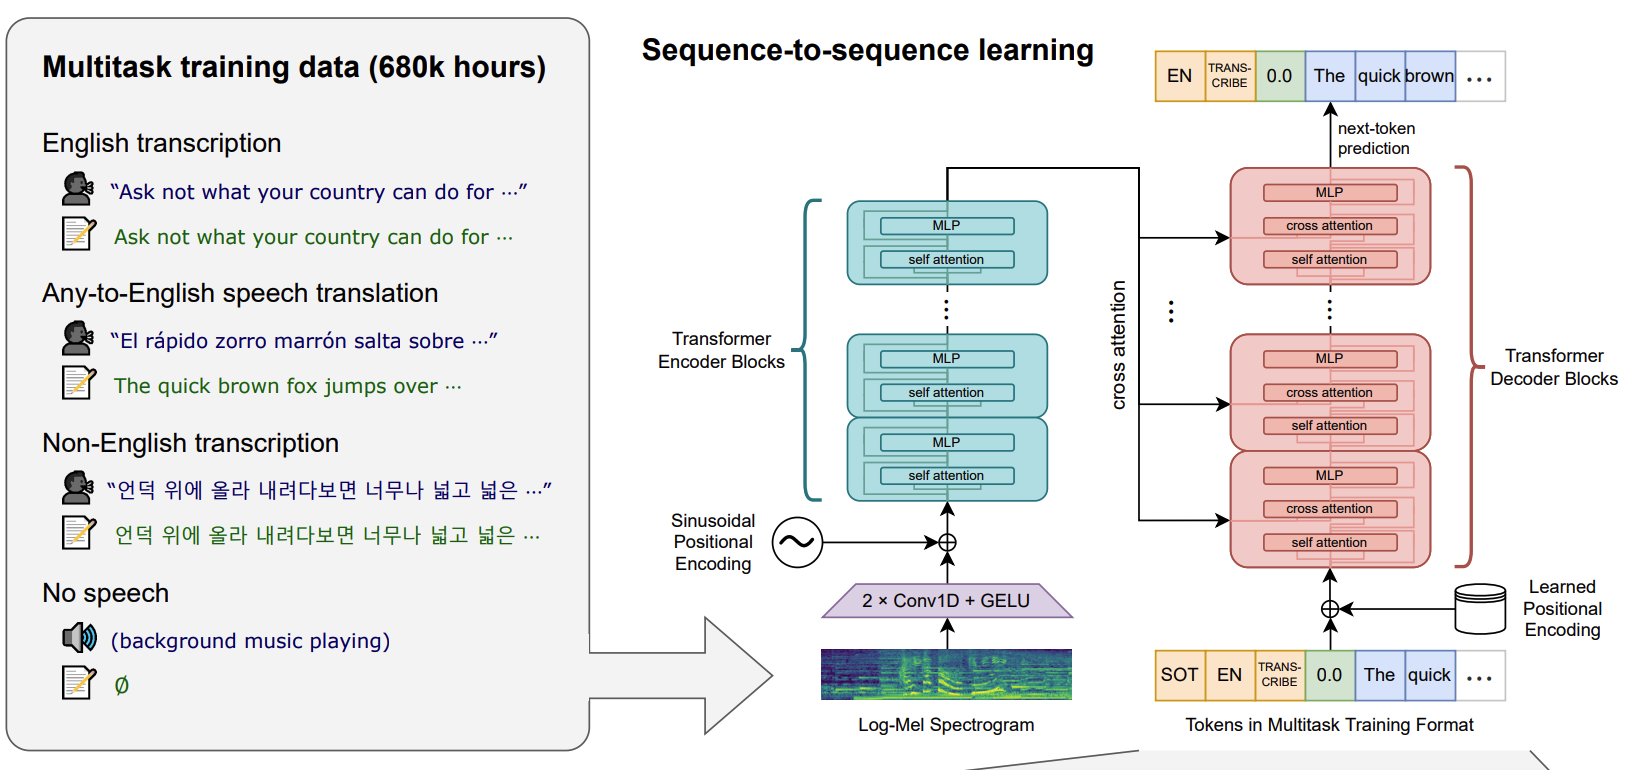  

### 2.2. Компьютерное зрение (Computer Vision)

#### 2.2.1. Подход на Attention (ViT - Vision Transformer)
*   **Концепция:** Замена сверток чистой Transformer-архитектурой.
*   **Входные данные:**
    1.  **Разбиение на патчи (Patching):** Изображение делится на квадратные неперекрывающиеся патчи (например, 16x16 -> 196 шт).
    2.  **Эмбеддинги патчей (Patch Embeddings):** Каждый патч проецируется в вектор (линейный слой/conv2d) размерности `D` (скрытая размерность модели).
    3.  **Специальные токены:** Добавляется learnable эмбеддинг `[CLS]`.
    4.  **Позиционные эмбеддинги:** Добавляются learnable позиционные эмбеддинги для сохранения пространственной структуры.
*   **Обработка:** Последовательность патч-эмбеддингов подается в стандартный Transformer-энкодер.
*   **Классификация:** Финальное скрытое состояние токена `[CLS]` подается в MLP-голову для получения логитов классов.
*   **Цель предобучения:** Классификация (кросс-энтропия).

#### 2.2.2. Подход на Свертках (ConvNeXT)
*   **Концепция:** Современная CNN, использующая свертки, но редизайн архитектуры выполнен с учетом трендов из мира Transformers (например, макро-дизайн ResNeXt, обрамление групповой свертки, уменьшение числа активаций, инвертированные узкие места (inverted bottlenecks), большие размеры ядер).

#### 2.2.3. Специализированные Vision-архитектуры
*   **DETR (Detection Transformer):** Для детекции объектов. Энд-ту-энд Transformer, предсказывающий множество объектов (set prediction) и использующий двудольный матчинг (bipartite matching) для функции потерь.
*   **Mask2Former:** Унифицированная архитектура для сегментации (семантической, экземплярной, паноптической). Использует masked attention Transformer для агрегации признаков.
*   **GLPN (Global-Local Path Network):** Для оценки глубины (depth estimation). Сочетает локальные признаки (свертки) и глобальный контекст (трансформеры).

---

### 3. Ключевые Паттерны и Выводы
*   **Унификация архитектур:** После предобучения, базовая модель (BERT, BART, ViT) служит экстрактором признаков. Смена задачи достигается заменой "головы" (head) — линейного слоя или небольшой сети поверх финальных скрытых состояний.
*   **Маскирование как фундаментальный паттерн:**
    *   **BERT:** Маскирование токенов (MLM) для двунаправленного понимания.
    *   **GPT:** Маскирование внимания (Causal Mask) для авторегрессии.
    *   **BART:** Маскирование спэнов (Text Infilling) для денойзинг-претрейнинга.
*   **Позиционная информация:** Всегда явно добавляется к входным эмбеддингам (learnable или фиксированные синусоидальные позиции для текста, learnable позиции патчей для изображений, временная размерность для аудио).

# Choosing the right architecture

When working on a specific NLP task, how do you decide which architecture to use? Here's a quick guide:

| Task | Suggested Architecture | Examples |
|------|------------------------|----------|
| Text classification (sentiment, topic) | Encoder | BERT, RoBERTa |
| Text generation (creative writing) | Decoder | GPT, LLaMA |
| Translation | Encoder-Decoder | T5, BART |
| Summarization | Encoder-Decoder | BART, T5 |
| Named entity recognition | Encoder | BERT, RoBERTa |
| Question answering (extractive) | Encoder | BERT, RoBERTa |
| Question answering (generative) | Encoder-Decoder or Decoder | T5, GPT |
| Conversational AI | Decoder | GPT, LLaMA |

## 3. Inference with LLMs

Инференс - это процесс, в котором LLM генерирует текст по данному ему промпту.
Модель генерирует по одному слову за раз, вычисляя вероятности следующих возможных токенов, используя выученные веса.

#### Роль внимания

Механизм внимания позволяет определять самые релеватные слова из уже прошедших сеть, давая им соотвествующий скор. По сути, это способность искать для генерации текста самую релевантную информацию

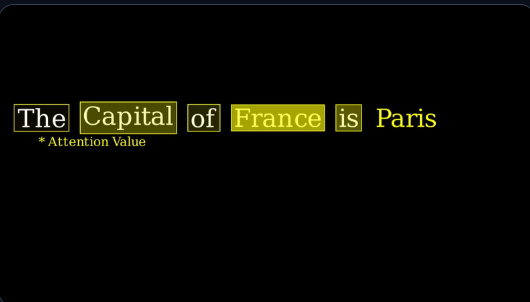

Длина контекста - кол-во токенов, которые модель может обработать за раз.

#### Два этапа инференса

Процесс инференса разбит на две фазы - prefill и decode. Эти стадии работают как пайплайн.

**Prefill**

1. Токенизация - конвертирует входной текст в токены.
2. Трансформация токенов в эмбеддинги
3. Инициализация - прогон этих эмбеддингов через модель для формирования понримания контекста

**Decode**

Здесь происходит генерация нового текста. Модель генерирует по одному токену за раз, это называется *авторегрессией* - где следующий токен зависит от всех предыдущих.

Стадия декодирования включает в себя несколько ключевых этапов:

1. Вычисление внимания. Вычисляем внимание, смотря на предыдущие токены для понимания контекста.
2. Вычисление вероятностей следующих токенов - получаем вероятностное растпределение следующих токенов.
3. Выбираем следующий токен основываясь на полученном распределении.
4. Проверяем, продолжаем ли мы процесс (тогда передаем полученный токен на вход), или заканчиваем если получили \<eof>

Процесс очень затратный по памяти, потому что модели приходится каждый раз прогонять всю последовательность через конеткст.

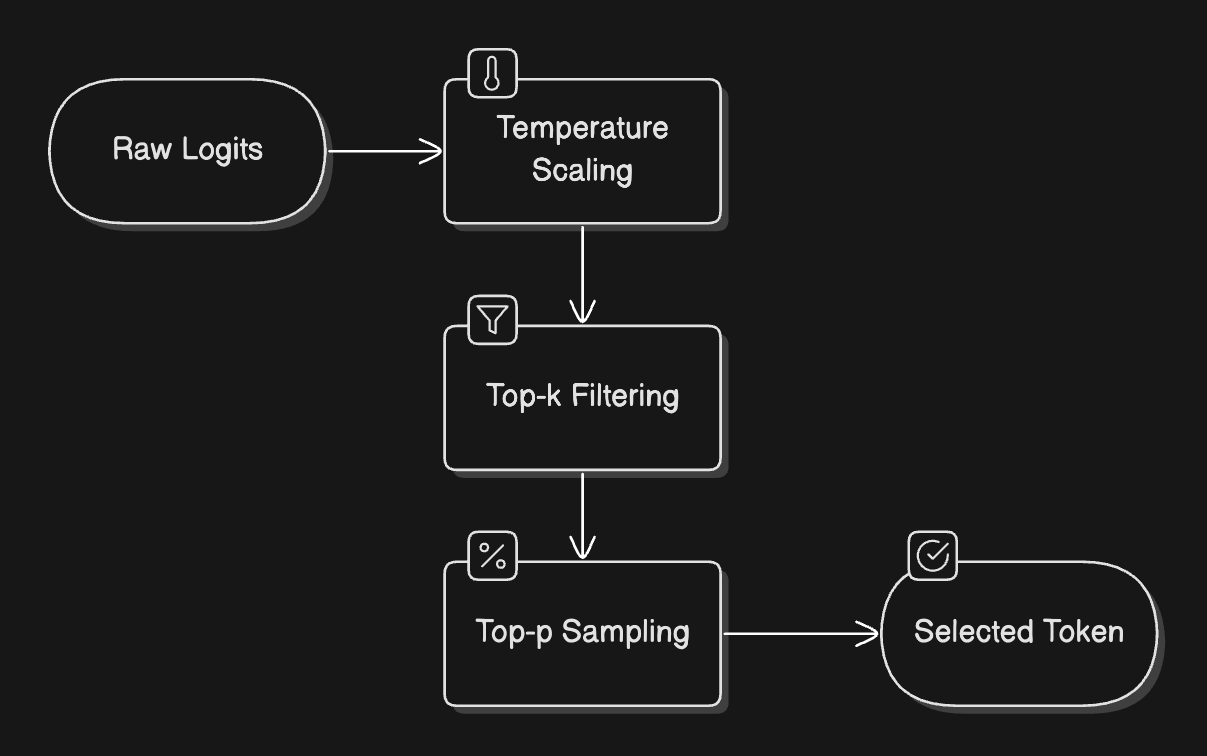



#### Склонность модели повторяться

Одна из распространенных проблем LLM - склонность возвращаться к одним и тем же тезисам при генерации текста. Во избежании, введены два вида штрафов:

1. Штраф по появлению - накладывается, если токен всречался раньше, не важно как часто.
2. Штраф по частоте появления. Он тем больше, чем больше частота появление токена ранее.

Эти штрафы накладываются на этапе ПОСЛЕ получения логитов, но до софтмакса.

#### Контроль длины выдачи

Мы должны иметь интрумент контроля модели за тем, сколько текста она генерирует. Есть несколько способов это делать:

1. Лимит по токенам. Можно задать минималько и максимальное кол-во токенов в выдаче. *Минусы*: Если использовать жесткий лимит, модель может обрубить ответ на полуслове.
2. Стоп-последовательности. Задать специальные паттерны, обозначающие конец генерации - "Если увидишь эту часть - заканчивай". То есть, если модель сгенерировала /n/n, например, что означает конец абзаца, то если задание было - сгенерировать какой-то текст в рамках абзаца, модель может заканчивать.
3. Детекция конца генерации. Дать модели самой завершить свой ответ - она сгенеирует токен \<eos> и остановится.

#### Beam Search (лучевой поиск)

Проблема жпдного поиска - выбираем по одному токену каждый раз, что ведет к скучным, повторяющимся или зацикленным фразам.

Решение - модель держит в уме несколько "лучей" - гипотез о продолжении генерации одновременно. Модель генерирует несколько вариантов развития событий на некоторое кол-во токенов наперед, а затем перемножает вероятности в этом луче, получая финальную вероятность всего луча.

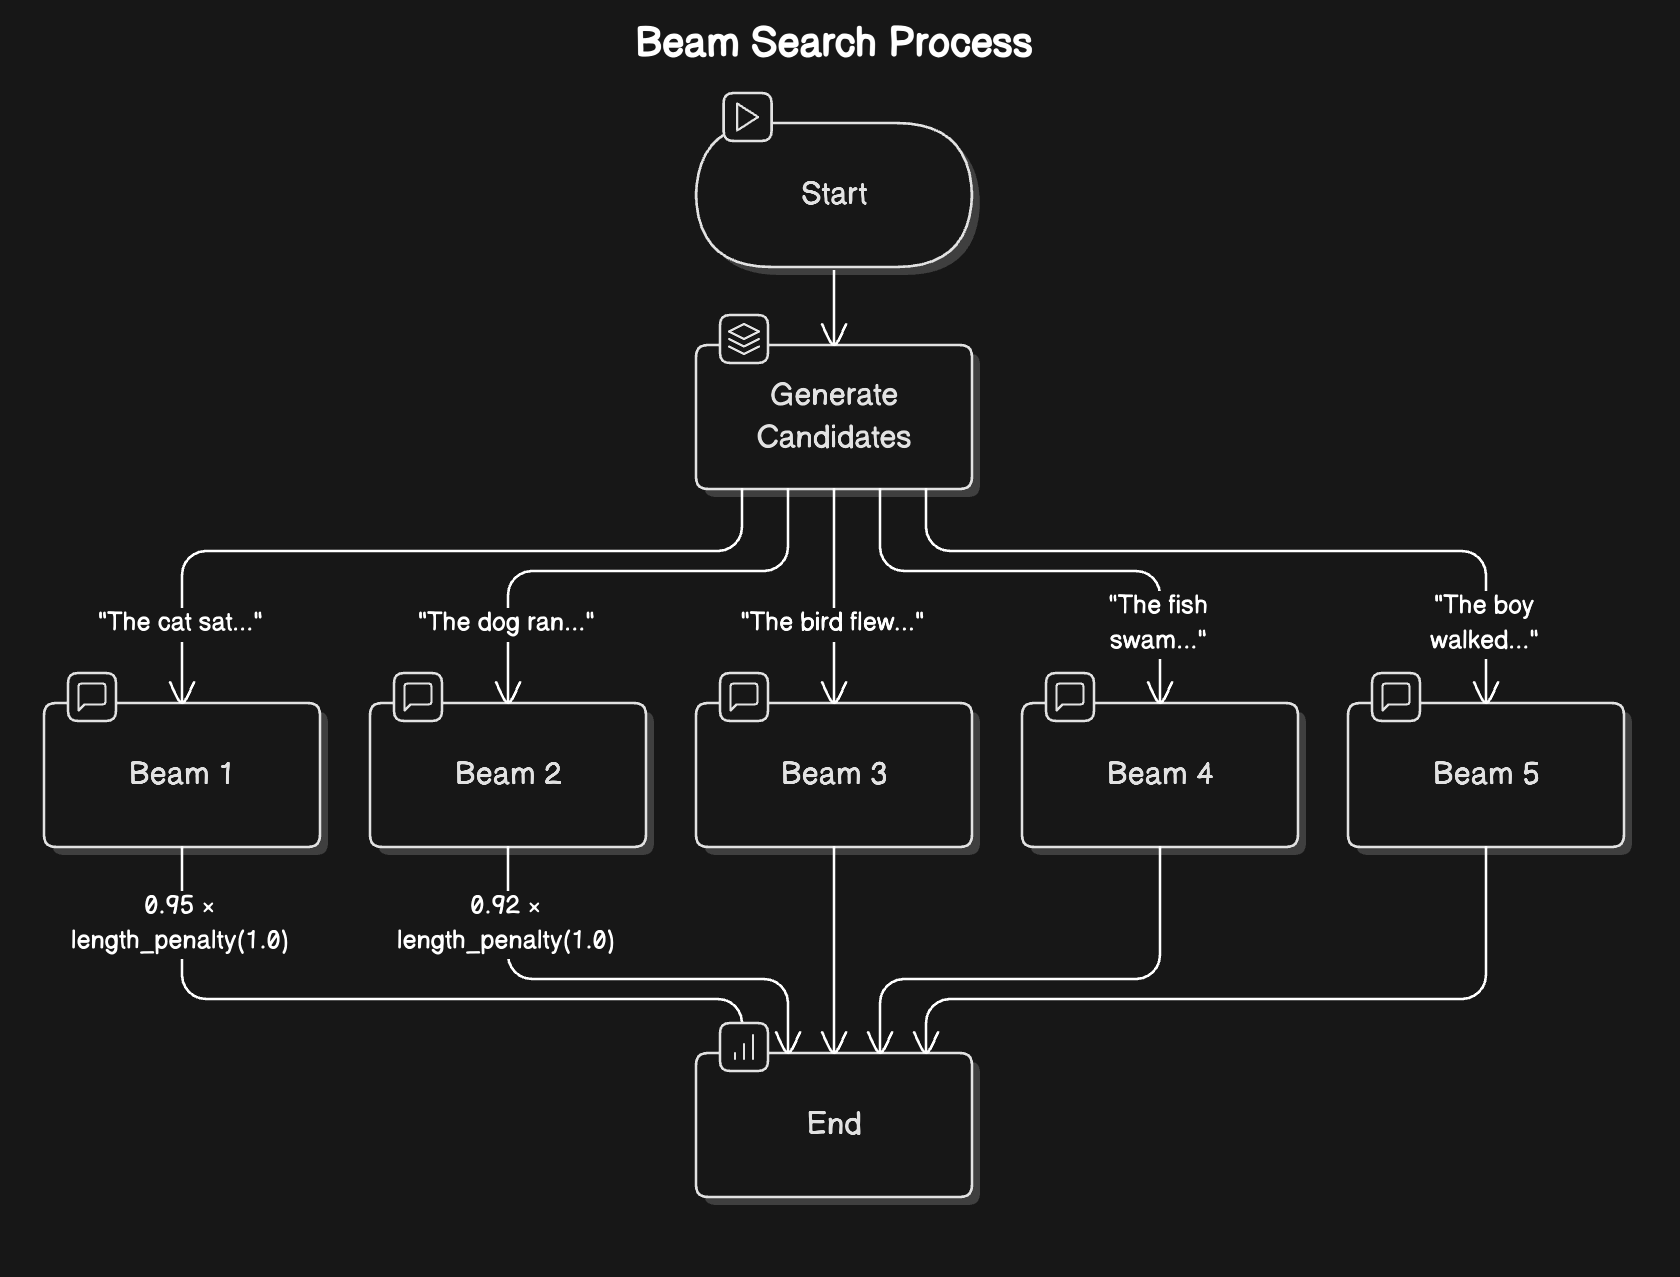





#### Ключевые метрики производительности инференса

1. Time To First Token (TTFT): Как быстро будет сгенерирован первый вывод? Метрика критична для User Experience, на нее сильно влияет фаза Prefill
2. Time Per Output Token (TPOT): Как быстро генерируем следующий токен? Это определяет среднее время генерации
3. Throughput. Какое кол-во запросов модель может обработать одновременно? Это влияет на масштабируемость и эффективность в стоимости.
4. VRAM Usage. Сколько GPU нужно для инференса? Это очень важная метрика, позволяюащя в реальных проектах определить применимость той или иной модели относительно лоступных ресурсов.

#### Зависимость ключевых показателей от длины контекста

Одна из самых существенных проблем LLM - обеспечить эффективность размера контекстного окна. Большие контекстные окна позволяют держать в памяти LLM больше контекста, однако влияют на следуюшие показатели:

1. Изпользование памяти - растет квадратично с ростом контекстного окна
2. Быстрота обработки - линейно падает вместе с ростом контекстного окна
3. Использование ресурсов - требует тщательного контроля за использованием видеопамяти.

Одно из решений для понижеия влияния величины контекстного окна - KV- оптимизация - повышаем использование памяти, кешируя K, V матрицы с уже рассчитанными значениями, при этом снижаем время инференса.